# Auckland Natural Hazard Asset Loss Engine

**Executed technical walkthrough**  
This notebook explains the verified project outputs from public Auckland Council asset locations and coastal-inundation extents. Financial values and damage functions are transparent illustrative assumptions, not Council financial data.

In [1]:
from pathlib import Path
import json, sqlite3
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
OUTPUTS = ROOT / 'outputs'
pd.set_option('display.float_format', lambda value: f'{value:,.2f}')
print(f'Project root: {ROOT}')

Project root: /workspace/scratch/d239d61ebbdb/auckland-asset-risk


## 1. Load verified pipeline outputs

The production pipeline handles ArcGIS REST pagination, standardisation, geometry validation, spatial exposure, Monte Carlo loss, SQLite loading and reporting. This notebook reads the generated outputs so the analysis remains reproducible and easy to review.

In [2]:
summary = pd.read_csv(OUTPUTS / 'scenario_summary.csv')
curve = pd.read_csv(OUTPUTS / 'loss_exceedance_curve.csv')
register = pd.read_csv(OUTPUTS / 'asset_risk_register.csv')
quality = json.loads((OUTPUTS / 'data_quality_report.json').read_text())
run = json.loads((OUTPUTS / 'run_metadata.json').read_text())

print(f"Assets assessed: {quality['record_count']:,}")
print(f"Monte Carlo iterations: {run['monte_carlo_iterations']:,}")
print(f"Duplicate business-ID records retained and flagged: {quality['duplicate_asset_id_records']}")
display(summary.style.format({
    'expected_annual_loss_nzd': 'NZ${:,.0f}',
    'portfolio_value_nzd': 'NZ${:,.0f}',
    'p90_curve_eal_nzd': 'NZ${:,.0f}'
}))

Assets assessed: 2,022
Monte Carlo iterations: 10,000
Duplicate business-ID records retained and flagged: 3


,scenario,expected_annual_loss_nzd,assets_with_modelled_loss,portfolio_value_nzd,p90_curve_eal_nzd
0,baseline,"NZ$788,977",38,"NZ$2,139,570,000","NZ$954,348"
1,slr_1m,"NZ$6,458,126",219,"NZ$2,139,570,000","NZ$10,194,553"
2,slr_1m_mitigated,"NZ$4,197,782",219,"NZ$2,139,570,000","NZ$6,605,028"


## 2. Financial-loss formulation

For exposed asset $i$, event $e$ and scenario $s$:

$$L_{i,e,s} = I_{i,e,s} \times V_i \times DR_e \times M_s$$

$I$ is spatial exposure, $V$ is illustrative replacement value, $DR$ is uncertain conditional damage ratio and $M$ is the treatment multiplier. The 10,000-iteration simulation propagates asset-value, vulnerability and systematic event uncertainty.

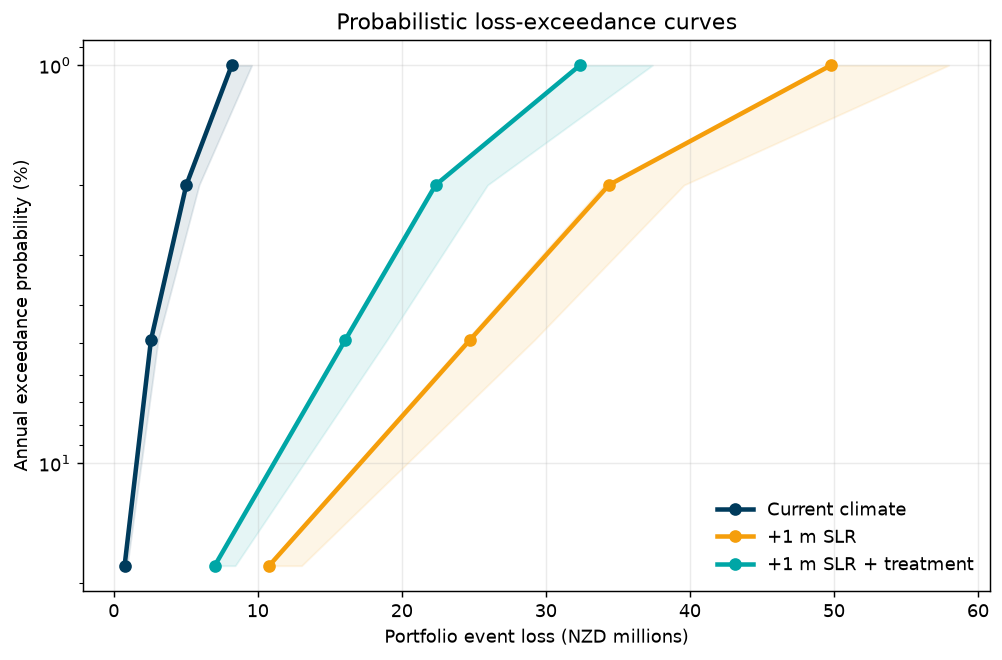

In [3]:
labels = {'baseline':'Current climate', 'slr_1m':'+1 m SLR', 'slr_1m_mitigated':'+1 m SLR + treatment'}
colors = {'baseline':'#003b5c', 'slr_1m':'#f59e0b', 'slr_1m_mitigated':'#00a6a6'}
fig, ax = plt.subplots(figsize=(9, 5.5))
for scenario, group in curve.groupby('scenario'):
    group = group.sort_values('aep')
    ax.plot(group.expected_loss_nzd / 1e6, group.aep * 100, marker='o', linewidth=2.5, label=labels[scenario], color=colors[scenario])
    ax.fill_betweenx(group.aep * 100, group.p50_loss_nzd / 1e6, group.p90_loss_nzd / 1e6, alpha=.10, color=colors[scenario])
ax.set(xlabel='Portfolio event loss (NZD millions)', ylabel='Annual exceedance probability (%)', title='Probabilistic loss-exceedance curves')
ax.set_yscale('log'); ax.invert_yaxis(); ax.grid(alpha=.25); ax.legend(frameon=False)
plt.show()

## 3. Geospatial decision prioritisation

Expected annual loss is adjusted by configured service criticality. This creates a transparent investigation priority—not a benefit-cost ratio.

,description,asset_type,local_board,replacement_value_nzd,expected_annual_loss_nzd,criticality_score,priority_score,risk_band
2022,Central Toilet and Changing Room - Whlm,Toilet/Changing,Rodney,"NZ$800,000","NZ$74,588",3,"96,964",Very high
2023,Changing room area,Changing Shed,Franklin,"NZ$650,000","NZ$60,603",2,"69,693",Very high
2024,Changing Room,Changing Shed,Orakei,"NZ$650,000","NZ$60,603",2,"69,693",Very high
2025,Changing room area,Changing Shed,Franklin,"NZ$650,000","NZ$60,603",2,"69,693",Very high
2026,Changing Room-(huia Domain) Bch Front,Changing Shed,Waitakere Ranges,"NZ$650,000","NZ$60,603",2,"69,693",Very high
2027,Change Room,Changing Shed,Mangere-Otahuhu,"NZ$650,000","NZ$60,603",2,"69,693",Very high
2028,Changing Rooms - Middle Of Domain,Changing Shed,Orakei,"NZ$650,000","NZ$60,603",2,"69,693",Very high
2029,Toilet - W32 (Eric Armishaw Park),Public Toilet,Albert-Eden,"NZ$450,000","NZ$41,956",3,"54,542",Very high
2030,Toilet - W4 Heritage Toilet/change,Public Toilet,Whau,"NZ$450,000","NZ$41,956",3,"54,542",Very high
2031,Toilet - W3 Novaloo (Bhb Beach),Public Toilet,Whau,"NZ$450,000","NZ$41,956",3,"54,542",Very high


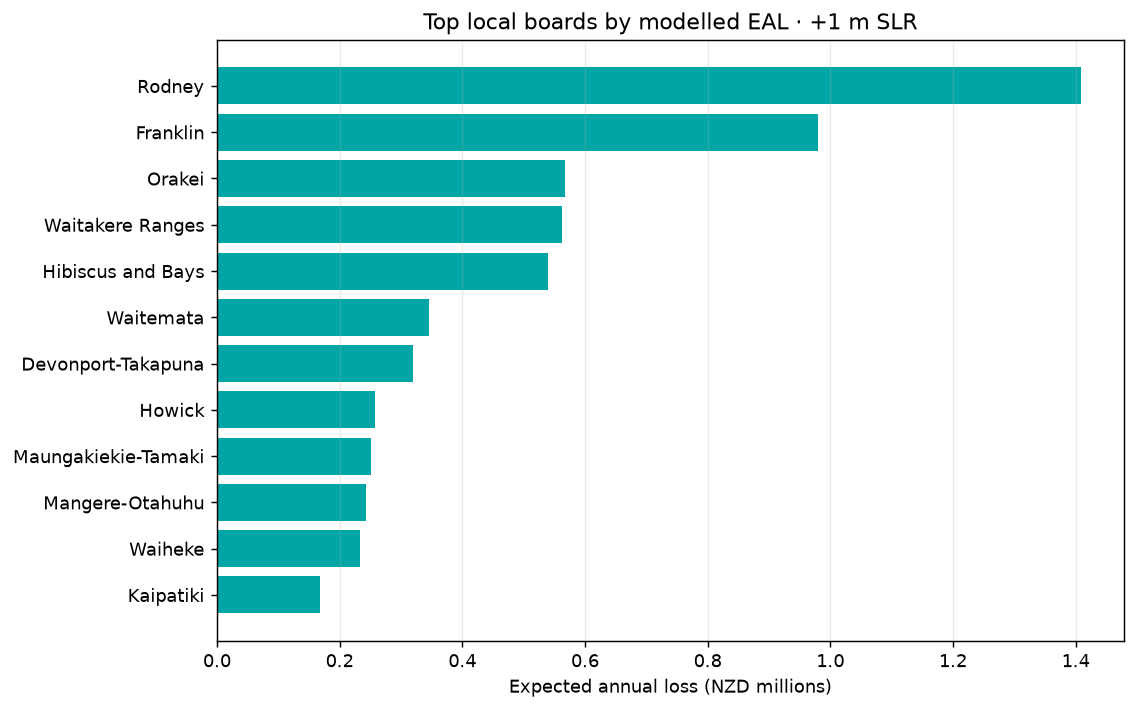

In [4]:
slr = register.query("scenario == 'slr_1m'").copy()
board = slr.groupby('local_board', as_index=False).expected_annual_loss_nzd.sum().nlargest(12, 'expected_annual_loss_nzd').sort_values('expected_annual_loss_nzd')
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(board.local_board, board.expected_annual_loss_nzd / 1e6, color='#00a6a6')
ax.set(xlabel='Expected annual loss (NZD millions)', title='Top local boards by modelled EAL · +1 m SLR')
ax.grid(axis='x', alpha=.25); plt.show()

top_columns = ['description','asset_type','local_board','replacement_value_nzd','expected_annual_loss_nzd','criticality_score','priority_score','risk_band']
display(slr.nlargest(10, 'priority_score')[top_columns].style.format({
    'replacement_value_nzd':'NZ${:,.0f}', 'expected_annual_loss_nzd':'NZ${:,.0f}', 'priority_score':'{:,.0f}'
}))

## 4. Database management and reconciliation

The pipeline publishes normalised analytical tables and indexes into SQLite. This query confirms scenario totals directly from the database.

In [5]:
with sqlite3.connect(OUTPUTS / 'risk_model.db') as connection:
    sql_totals = pd.read_sql_query('''
        SELECT scenario, COUNT(*) AS asset_records,
               SUM(CASE WHEN expected_annual_loss_nzd > 0 THEN 1 ELSE 0 END) AS assets_with_loss,
               ROUND(SUM(expected_annual_loss_nzd), 2) AS expected_annual_loss_nzd
        FROM asset_risk_register
        GROUP BY scenario ORDER BY scenario
    ''', connection)
display(sql_totals.style.format({'expected_annual_loss_nzd':'NZ${:,.2f}'}))

,scenario,asset_records,assets_with_loss,expected_annual_loss_nzd
0,baseline,2022,38,"NZ$788,976.75"
1,slr_1m,2022,219,"NZ$6,458,126.50"
2,slr_1m_mitigated,2022,219,"NZ$4,197,782.22"


## 5. Why extent-based vulnerability is used

The public layers provide event inundation extents, not flood-depth rasters at each asset. A DEM by itself cannot create depth because a defensible event water-surface elevation is also required. Inventing a water surface would create false precision.

This project therefore uses real mapped extent with explicit conditional-damage uncertainty. The model can accept calibrated depth-damage functions when authoritative event-depth outputs become available.

In [6]:
for scenario, group in curve.groupby('scenario'):
    ordered = group.sort_values('aep', ascending=False)
    assert ordered.exposed_assets.is_monotonic_increasing
    assert ordered.expected_loss_nzd.is_monotonic_increasing
csv_totals = summary.set_index('scenario').expected_annual_loss_nzd.sort_index()
db_totals = sql_totals.set_index('scenario').expected_annual_loss_nzd.sort_index()
assert np.allclose(csv_totals, db_totals, atol=.01)
print('QA passed: monotonic exposure/loss and database reconciliation for all scenarios.')

QA passed: monotonic exposure/loss and database reconciliation for all scenarios.


## 6. Decision interpretation and limitations

The model identifies assets and local boards that warrant detailed investigation under present-day and +1 m sea-level-rise extents. A configurable treatment scenario demonstrates avoided-loss analysis.

The results are portfolio-screening outputs. Replacement values and vulnerability functions are illustrative; point exposure does not represent full footprints; coastal inundation is only one hazard; and investment decisions require intervention cost, remaining life, service dependency, equity and engineering verification.

In [7]:
result = summary.set_index('scenario').expected_annual_loss_nzd
avoided = result['slr_1m'] - result['slr_1m_mitigated']
print(f"Current-climate illustrative EAL: NZ${result['baseline']/1e6:.2f}m")
print(f"+1 m SLR illustrative EAL: NZ${result['slr_1m']/1e6:.2f}m")
print(f"Illustrative annual loss avoided by configured treatment: NZ${avoided/1e6:.2f}m")

Current-climate illustrative EAL: NZ$0.79m
+1 m SLR illustrative EAL: NZ$6.46m
Illustrative annual loss avoided by configured treatment: NZ$2.26m
